In [47]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

In [1]:
print("hello")

hello


In [48]:
np.random.seed(42)
random.seed(42)

In [26]:
courses = {
    'BA' :  {'type':'UG',  'years':3, 'subjects': ['Hindi','English','History', 'Political Science', 'Geography'], 'count': 1800},
    'BSc':  {'type': 'UG', 'years': 3, 'subjects': ['Physics', 'Chemistry', 'Maths', 'Biology'],               'count': 1400},
    'BCom': {'type': 'UG', 'years': 3, 'subjects': ['Accountancy', 'Economics', 'Business Law', 'Finance'],    'count': 1000},
    # PG Courses (2 years)
    'MA':   {'type': 'PG', 'years': 2, 'subjects': ['Hindi', 'English', 'History', 'Political Science'],         'count': 400},
    'MSc':  {'type': 'PG', 'years': 2, 'subjects': ['Physics', 'Chemistry', 'Maths', 'Biology'],                 'count': 250},
    'MCom': {'type': 'PG', 'years': 2, 'subjects': ['Accountancy', 'Economics', 'Business Law'],                 'count': 150},
}
    

In [29]:
rows = []
student_num = 1

In [49]:

for course,info in courses.items():
    for _ in range(info['count']):
        year = random.randint(1,info['years'])
        gender = random.choice(['Male','Female'])
        age = random.randint(18,22) if info['type'] == 'UG' else random.randint(21,25)

        # Fee structure
        fee_map = {'BA': 8000, 'BSc': 12000, 'BCom': 10000, 'MA': 10000, 'MSc': 15000, 'MCom': 12000}
        fee_total = fee_map[course]
        fee_paid = fee_total if random.random() > 0.28 else int(fee_total * random.uniform(0.2, 0.9))

        rows.append({
            'student_id':   f'GTC{str(student_num).zfill(4)}',
            'name':         f'Student_{student_num}',
            'course':       course,
            'course_type':  info['type'],
            'year':         year,
            'gender':       gender,
            'age':          age,
            'fee_total':    fee_total,
            'fee_paid':     fee_paid,
            'fee_pending':  fee_total - fee_paid,
            'fee_status':   'Paid' if fee_paid == fee_total else 'Pending',
        })
        student_num += 1

    

In [31]:
df_students = pd.DataFrame(rows)

In [34]:
print(f"Total Students : {len(df_students)}")
print(df_students['course'].value_counts())
print(df_students['course_type'].value_counts())


Total Students : 5000
course
BA      1800
BSc     1400
BCom    1000
MA       400
MSc      250
MCom     150
Name: count, dtype: int64
course_type
UG    4200
PG     800
Name: count, dtype: int64


In [37]:
df_students.head(10)

,student_id,name,course,course_type,year,gender,age,fee_total,fee_paid,fee_pending,fee_status
0,GTC0001,Student_1,BA,UG,2,Female,18,8000,8000,0,Paid
1,GTC0002,Student_2,BA,UG,2,Female,19,8000,3046,4954,Pending
2,GTC0003,Student_3,BA,UG,2,Male,21,8000,8000,0,Paid
3,GTC0004,Student_4,BA,UG,2,Male,19,8000,8000,0,Paid
4,GTC0005,Student_5,BA,UG,2,Male,22,8000,6156,1844,Pending
5,GTC0006,Student_6,BA,UG,1,Female,22,8000,6361,1639,Pending
6,GTC0007,Student_7,BA,UG,1,Female,22,8000,3778,4222,Pending
7,GTC0008,Student_8,BA,UG,3,Female,21,8000,8000,0,Paid
8,GTC0009,Student_9,BA,UG,1,Male,21,8000,8000,0,Paid
9,GTC0010,Student_10,BA,UG,2,Female,19,8000,1876,6124,Pending


In [38]:
df_students.columns

Index(['student_id', 'name', 'course', 'course_type', 'year', 'gender', 'age',
       'fee_total', 'fee_paid', 'fee_pending', 'fee_status'],
      dtype='object')

In [40]:
attendance_rows = []
# Working days per month (college calendar)
months = ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
working_days = [26, 25, 24, 23, 20, 18, 22, 24, 26, 25]

In [41]:
for _, student in df_students.iterrows():
    for month, total_days in zip(months, working_days):
        
        # Realistic attendance pattern
        # PG students slightly more regular than UG
        if student['course_type'] == 'PG':
            attendance_pct = random.gauss(0.82, 0.10)
        else:
            attendance_pct = random.gauss(0.75, 0.12)
        
        # Clamp between 0.3 and 1.0
        attendance_pct = max(0.30, min(1.0, attendance_pct))
        
        days_present = round(total_days * attendance_pct)
        
        attendance_rows.append({
            'student_id':    student['student_id'],
            'course':        student['course'],
            'course_type':   student['course_type'],
            'year':          student['year'],
            'month':         month,
            'total_days':    total_days,
            'days_present':  days_present,
            'attendance_pct': round(attendance_pct * 100, 2)
        })

df_attendance = pd.DataFrame(attendance_rows)


In [42]:
# Overall attendance per student
df_avg_attendance = df_attendance.groupby('student_id').agg(
    total_days    = ('total_days', 'sum'),
    days_present  = ('days_present', 'sum')
).reset_index()
df_avg_attendance['overall_attendance_pct'] = round(
    df_avg_attendance['days_present'] / df_avg_attendance['total_days'] * 100, 2
)
df_avg_attendance['attendance_category'] = df_avg_attendance['overall_attendance_pct'].apply(
    lambda x: 'Good (75%+)' if x >= 75 else 'Low (<75%)'
)


In [74]:
print(" Attendance Data Ready!")
print(f"Total Records : {len(df_attendance)}")
print(f"\nAttendance Category Distribution:")
print(df_avg_attendance['attendance_category'].value_counts())
print(f"\nAverage Attendance % by Course:")
print(df_attendance.groupby('course')['attendance_pct'].mean().round(2))

df_attendance.head()

 Attendance Data Ready!
Total Records : 50000

Attendance Category Distribution:
attendance_category
Good (75%+)    2943
Low (<75%)     2057
Name: count, dtype: int64

Average Attendance % by Course:
course
BA      74.82
BCom    74.94
BSc     75.05
MA      81.90
MCom    81.71
MSc     82.14
Name: attendance_pct, dtype: float64


,student_id,course,course_type,year,month,total_days,days_present,attendance_pct
0,GTC0001,BA,UG,2,Jul,26,16,61.05
1,GTC0001,BA,UG,2,Aug,25,16,64.59
2,GTC0001,BA,UG,2,Sep,24,15,63.55
3,GTC0001,BA,UG,2,Oct,23,19,81.49
4,GTC0001,BA,UG,2,Nov,20,16,80.01


In [44]:
# ─── MARKS / RESULT DATA ─────────────────────────────────────────

subjects_map = {
    'BA':   ['Hindi', 'English', 'History', 'Political Science', 'Geography'],
    'BSc':  ['Physics', 'Chemistry', 'Maths', 'Biology'],
    'BCom': ['Accountancy', 'Economics', 'Business Law', 'Finance'],
    'MA':   ['Hindi', 'English', 'History', 'Political Science'],
    'MSc':  ['Physics', 'Chemistry', 'Maths', 'Biology'],
    'MCom': ['Accountancy', 'Economics', 'Business Law'],
}

In [76]:
marks_rows = []

for _, student in df_students.iterrows():
    subjects = subjects_map[student['course']]
    
    # Attendance ka marks pe impact
    student_attendance = df_avg_attendance[
        df_avg_attendance['student_id'] == student['student_id']
    ]['overall_attendance_pct'].values[0]
    
    # Base performance level (attendance se linked)
    if student_attendance >= 75:
        base_marks = random.gauss(62, 12)
    else:
        base_marks = random.gauss(45, 15)
    
    for subject in subjects:
        marks = base_marks + random.gauss(0, 8)
        marks = max(0, min(100, round(marks, 1)))
        
        # Pass/Fail — passing marks 33
        status = 'Pass' if marks >= 33 else 'Fail'
        
        # Grade
        if marks >= 75:   grade = 'A'
        elif marks >= 60: grade = 'B'
        elif marks >= 45: grade = 'C'
        elif marks >= 33: grade = 'D'
        else:             grade = 'F'
        
        marks_rows.append({
            'student_id':    student['student_id'],
            'course':        student['course'],
            'course_type':   student['course_type'],
            'year':          student['year'],
            'subject':       subject,
            'marks':         marks,
            'max_marks':     100,
            'grade':         grade,
            'result':        status,
        })

df_marks = pd.DataFrame(marks_rows)

# Subject wise average
subject_avg = df_marks.groupby(['course', 'subject'])['marks'].mean().round(2)

print(" Marks Data Ready!")
print(f"Total Records : {len(df_marks)}")
print(f"\nOverall Pass/Fail:")
print(df_marks['result'].value_counts())
print(f"\nGrade Distribution:")
print(df_marks['grade'].value_counts())
print(f"\nCourse-wise Average Marks:")
print(df_marks.groupby('course')['marks'].mean().round(2))

df_marks.head(10)


 Marks Data Ready!
Total Records : 21650

Overall Pass/Fail:
result
Pass    19161
Fail     2489
Name: count, dtype: int64

Grade Distribution:
grade
C    6877
B    5998
D    3571
A    2715
F    2489
Name: count, dtype: int64

Course-wise Average Marks:
course
BA      53.67
BCom    53.53
BSc     54.16
MA      61.53
MCom    63.42
MSc     61.01
Name: marks, dtype: float64


,student_id,course,course_type,year,subject,marks,max_marks,grade,result
0,GTC0001,BA,UG,2,Hindi,41.0,100,D,Pass
1,GTC0001,BA,UG,2,English,53.8,100,C,Pass
2,GTC0001,BA,UG,2,History,45.4,100,C,Pass
3,GTC0001,BA,UG,2,Political Science,45.1,100,C,Pass
4,GTC0001,BA,UG,2,Geography,54.8,100,C,Pass
5,GTC0002,BA,UG,2,Hindi,33.4,100,D,Pass
6,GTC0002,BA,UG,2,English,38.5,100,D,Pass
7,GTC0002,BA,UG,2,History,40.5,100,D,Pass
8,GTC0002,BA,UG,2,Political Science,37.8,100,D,Pass
9,GTC0002,BA,UG,2,Geography,62.3,100,B,Pass


In [ ]:
# ─── SAVE ALL DATA TO CSV ─────────────────────────────────────────


In [51]:
df_students.to_csv('students.csv', index=False)
df_attendance.to_csv('attendance.csv', index=False)
df_avg_attendance.to_csv('avg_attendance.csv', index=False)
df_marks.to_csv('marks.csv', index=False)


In [77]:
print(" Sab CSV files save ho gayi!")
print("\nFiles saved:")
print("  → students.csv       :", len(df_students), "records")
print("  → attendance.csv     :", len(df_attendance), "records")
print("  → avg_attendance.csv :", len(df_avg_attendance), "records")
print("  → marks.csv          :", len(df_marks), "records")

 Sab CSV files save ho gayi!

Files saved:
  → students.csv       : 5000 records
  → attendance.csv     : 50000 records
  → avg_attendance.csv : 5000 records
  → marks.csv          : 21650 records


In [ ]:
#visualization 

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [63]:
#set style 
sns.set_theme(style = "whitegrid")
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11
print("Libraries ready!")


Libraries ready!


In [64]:
# ANALYSIS 1 — Course-wise Student Distribution

Text(0.5, 1.0, 'UG vs PG Distribution')

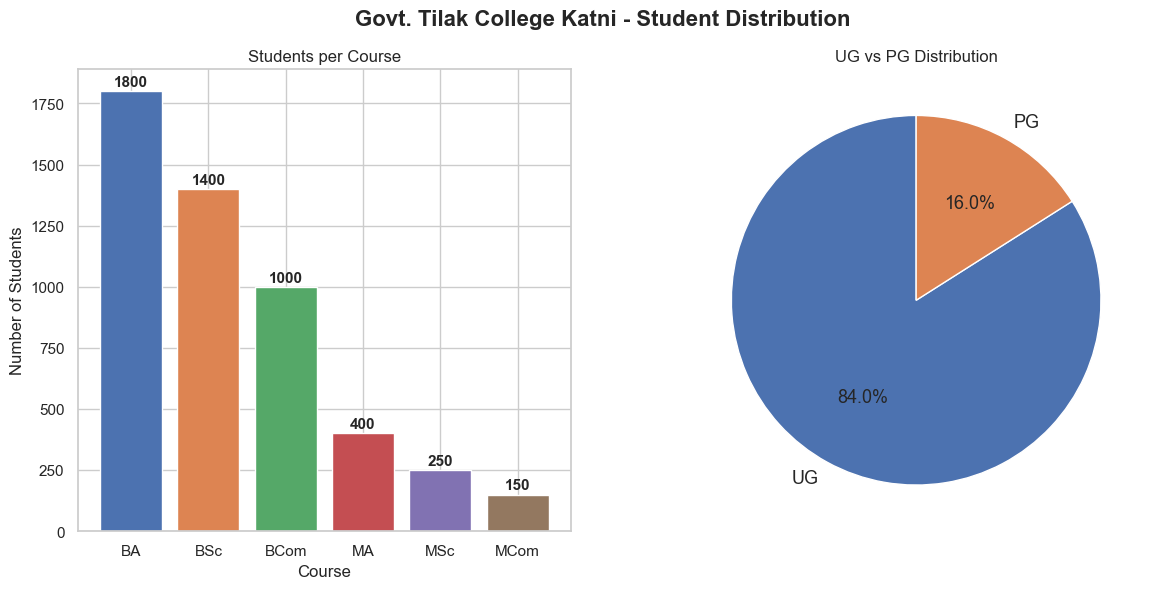

In [72]:
fig,axes = plt.subplots(1,2, figsize=(14,6))
fig.suptitle('Govt. Tilak College Katni - Student Distribution',fontsize=16,fontweight= 'bold')
# Chart 1 — Course wise bar chart
course_counts = df_students['course'].value_counts()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
axes[0].bar(course_counts.index, course_counts.values, color=colors)
axes[0].set_title('Students per Course')
axes[0].set_xlabel('Course')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(course_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
# Chart 2 — UG vs PG pie chart
ug_pg = df_students['course_type'].value_counts()
axes[1].pie(ug_pg.values, labels=ug_pg.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            textprops={'fontsize': 13})
axes[1].set_title('UG vs PG Distribution')    

In [73]:
plt.tight_layout()
plt.savefig('chart1_student_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

<Figure size 1200x600 with 0 Axes>

Chart 1 saved!


In [ ]:
 #ANALYSIS 2 — Attendance Analysis

(60.0, 90.0)

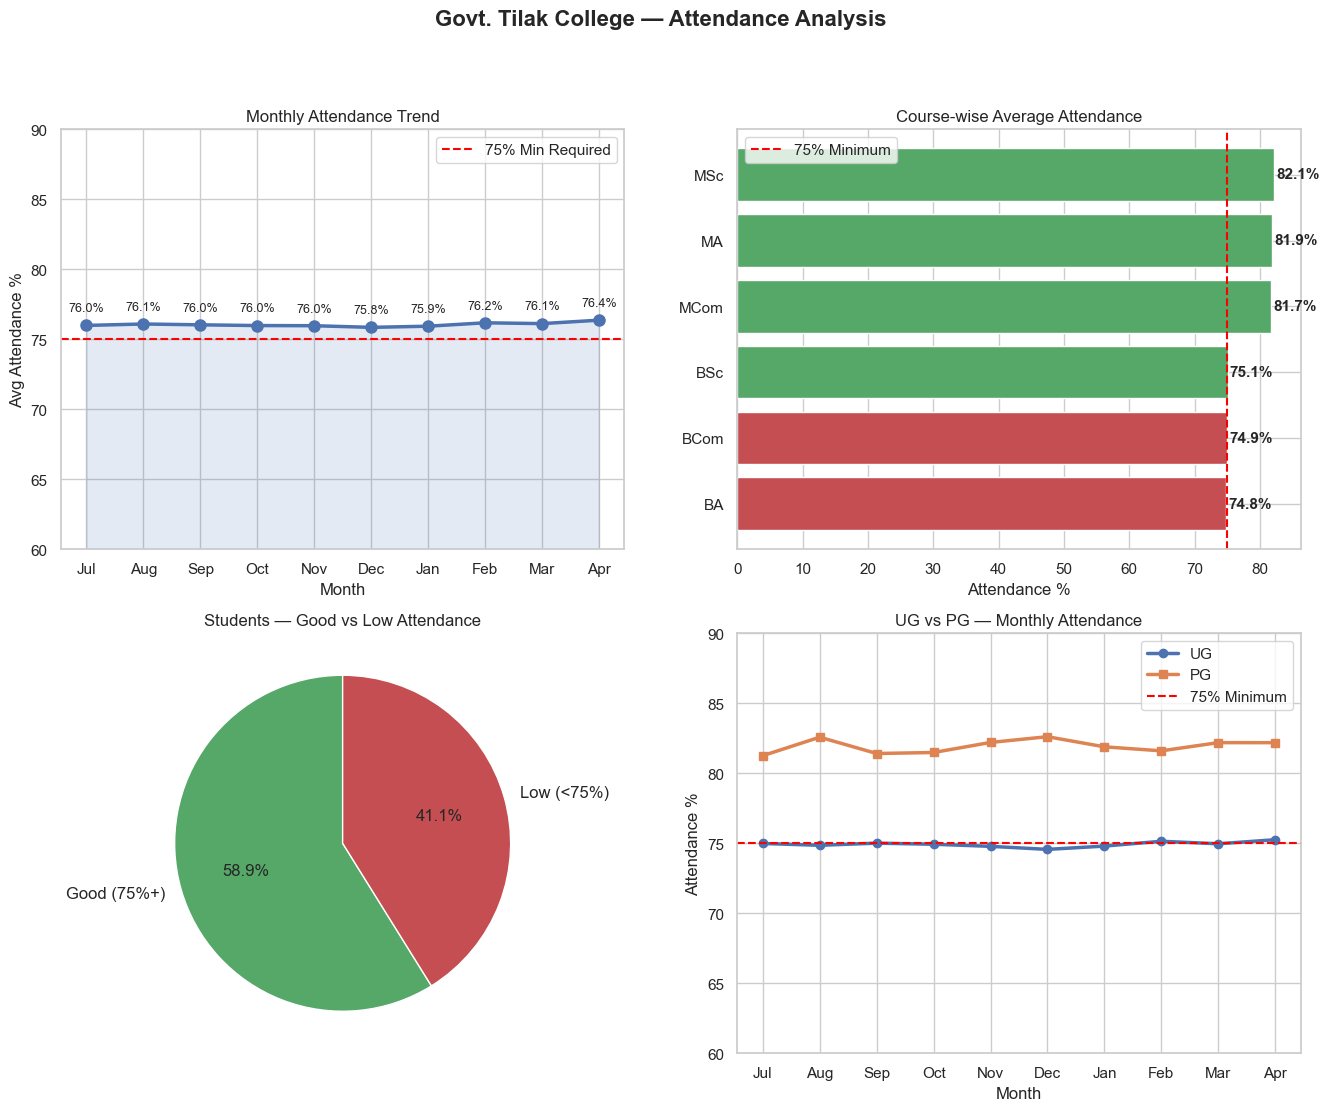

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Govt. Tilak College — Attendance Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Monthly Attendance Trend (all courses)
monthly_avg = df_attendance.groupby('month')['attendance_pct'].mean()
month_order = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr']
monthly_avg = monthly_avg.reindex(month_order)

axes[0,0].plot(monthly_avg.index, monthly_avg.values, 
               marker='o', linewidth=2.5, color='#4C72B0', markersize=8)
axes[0,0].axhline(y=75, color='red', linestyle='--', linewidth=1.5, label='75% Min Required')
axes[0,0].fill_between(monthly_avg.index, monthly_avg.values, alpha=0.15, color='#4C72B0')
axes[0,0].set_title('Monthly Attendance Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Avg Attendance %')
axes[0,0].legend()
axes[0,0].set_ylim(60, 90)
for i, (m, v) in enumerate(monthly_avg.items()):
    axes[0,0].annotate(f'{v:.1f}%', (m, v), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=9)

# Chart 2 — Course wise Attendance
course_att = df_attendance.groupby('course')['attendance_pct'].mean().sort_values()
colors_att = ['#C44E52' if x < 75 else '#55A868' for x in course_att.values]
axes[0,1].barh(course_att.index, course_att.values, color=colors_att)
axes[0,1].axvline(x=75, color='red', linestyle='--', linewidth=1.5, label='75% Minimum')
axes[0,1].set_title('Course-wise Average Attendance')
axes[0,1].set_xlabel('Attendance %')
axes[0,1].legend()
for i, v in enumerate(course_att.values):
    axes[0,1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# Chart 3 — Attendance Category Distribution
att_cat = df_avg_attendance['attendance_category'].value_counts()
colors_pie = ['#55A868', '#C44E52']
axes[1,0].pie(att_cat.values, labels=att_cat.index, autopct='%1.1f%%',
              colors=colors_pie, startangle=90, textprops={'fontsize': 12})
axes[1,0].set_title('Students — Good vs Low Attendance')

# Chart 4 — UG vs PG Attendance Comparison
ug_pg_att = df_attendance.groupby(['month', 'course_type'])['attendance_pct'].mean().unstack()
ug_pg_att = ug_pg_att.reindex(month_order)
axes[1,1].plot(ug_pg_att.index, ug_pg_att['UG'], 
               marker='o', linewidth=2.5, label='UG', color='#4C72B0')
axes[1,1].plot(ug_pg_att.index, ug_pg_att['PG'], 
               marker='s', linewidth=2.5, label='PG', color='#DD8452')
axes[1,1].axhline(y=75, color='red', linestyle='--', linewidth=1.5, label='75% Minimum')
axes[1,1].set_title('UG vs PG — Monthly Attendance')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Attendance %')
axes[1,1].legend()
axes[1,1].set_ylim(60, 90)

In [79]:
plt.tight_layout()
plt.savefig('chart2_attendance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

<Figure size 1200x600 with 0 Axes>

✅ Chart 2 saved!


In [80]:

# Low Attendance Students List
low_att = df_avg_attendance[df_avg_attendance['overall_attendance_pct'] < 75].merge(
    df_students[['student_id', 'course', 'year']], on='student_id'
)
print(f"\n⚠️  Low Attendance Students (below 75%): {len(low_att)}")
print(low_att[['student_id', 'course', 'year', 'overall_attendance_pct']].head(10))


⚠️  Low Attendance Students (below 75%): 2057
  student_id course  year  overall_attendance_pct
0    GTC0001     BA     2                   73.82
1    GTC0004     BA     2                   74.68
2    GTC0006     BA     1                   70.39
3    GTC0008     BA     3                   71.24
4    GTC0009     BA     1                   69.10
5    GTC0010     BA     2                   74.25
6    GTC0015     BA     2                   71.67
7    GTC0017     BA     2                   71.67
8    GTC0019     BA     1                   72.10
9    GTC0020     BA     3                   70.82


In [81]:
# ANALYSIS 3 — Marks & Result Analysis

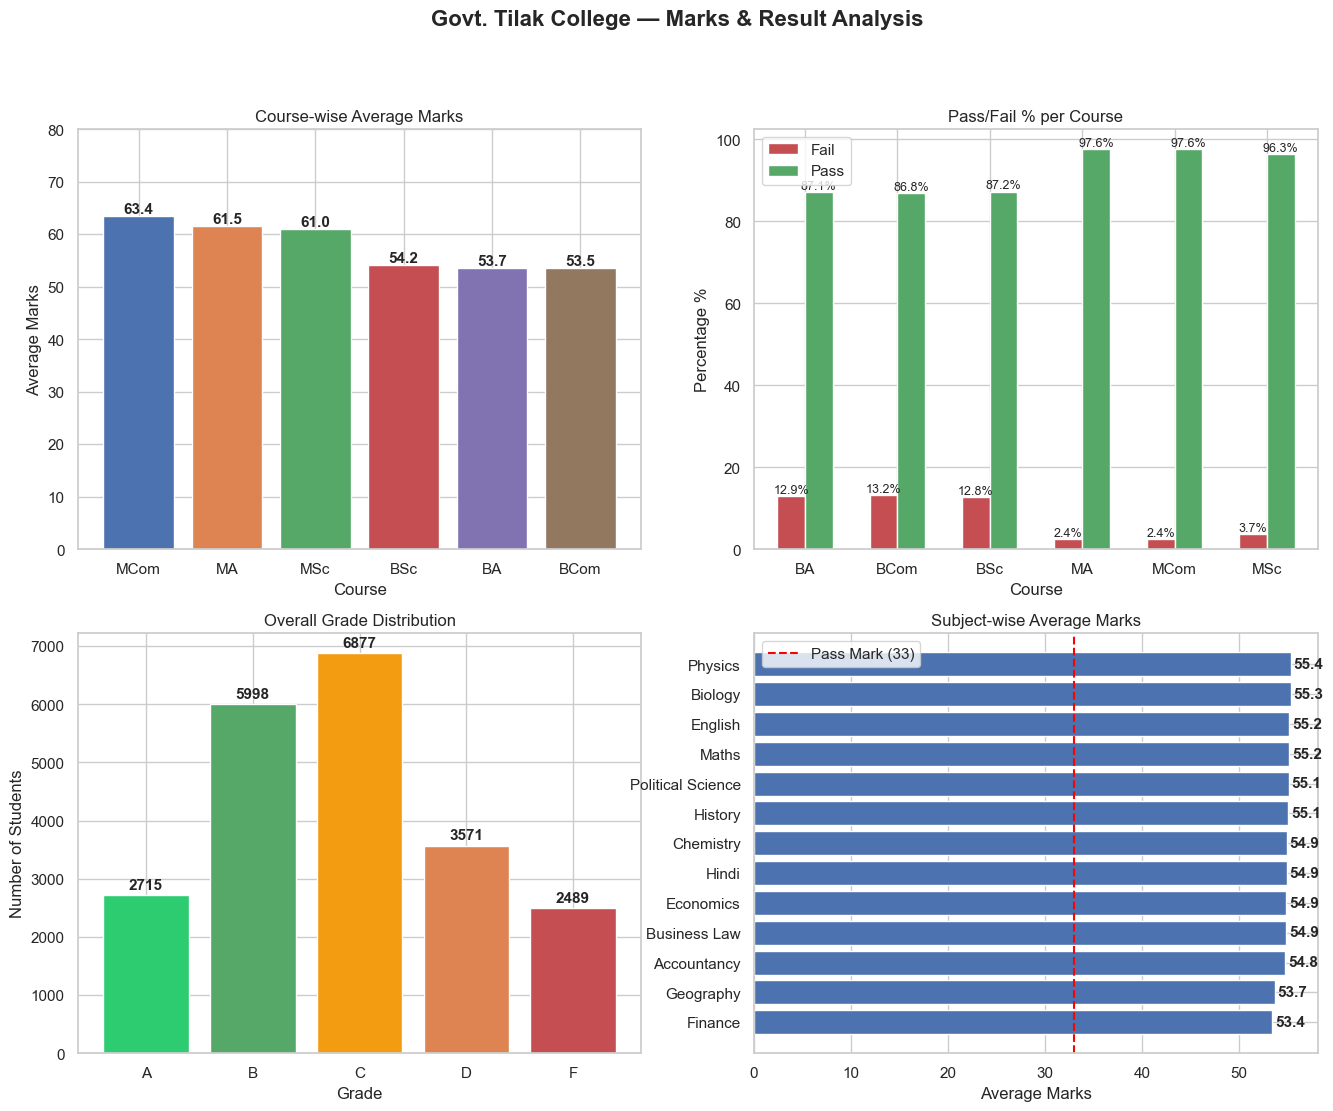

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Govt. Tilak College — Marks & Result Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Course wise Average Marks
course_marks = df_marks.groupby('course')['marks'].mean().sort_values(ascending=False)
colors_marks = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
bars = axes[0,0].bar(course_marks.index, course_marks.values, color=colors_marks)
axes[0,0].set_title('Course-wise Average Marks')
axes[0,0].set_xlabel('Course')
axes[0,0].set_ylabel('Average Marks')
axes[0,0].set_ylim(0, 80)
for bar, v in zip(bars, course_marks.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v + 0.5, 
                   f'{v:.1f}', ha='center', fontweight='bold')

# Chart 2 — Pass/Fail per Course
pass_fail = df_marks.groupby(['course', 'result']).size().unstack(fill_value=0)
pass_fail_pct = pass_fail.div(pass_fail.sum(axis=1), axis=0) * 100
pass_fail_pct.plot(kind='bar', ax=axes[0,1], 
                   color=['#C44E52', '#55A868'], 
                   edgecolor='white', width=0.6)
axes[0,1].set_title('Pass/Fail % per Course')
axes[0,1].set_xlabel('Course')
axes[0,1].set_ylabel('Percentage %')
axes[0,1].legend(['Fail', 'Pass'])
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.1f%%', fontsize=9)
    
# Chart 3 — Grade Distribution Overall
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df_marks['grade'].value_counts().reindex(grade_order)
grade_colors = ['#2ecc71', '#55A868', '#f39c12', '#DD8452', '#C44E52']
axes[1,0].bar(grade_counts.index, grade_counts.values, color=grade_colors)
axes[1,0].set_title('Overall Grade Distribution')
axes[1,0].set_xlabel('Grade')
axes[1,0].set_ylabel('Number of Students')
for i, v in enumerate(grade_counts.values):
    axes[1,0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Chart 4 — Subject wise Average Marks (top subjects)
subject_avg = df_marks.groupby('subject')['marks'].mean().sort_values(ascending=True)
axes[1,1].barh(subject_avg.index, subject_avg.values, color='#4C72B0')
axes[1,1].set_title('Subject-wise Average Marks')
axes[1,1].set_xlabel('Average Marks')
axes[1,1].axvline(x=33, color='red', linestyle='--', linewidth=1.5, label='Pass Mark (33)')
axes[1,1].legend()
for i, v in enumerate(subject_avg.values):
    axes[1,1].text(v + 0.3, i, f'{v:.1f}', va='center', fontweight='bold')

    

In [87]:
plt.tight_layout()
plt.savefig('chart3_marks_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

<Figure size 1200x600 with 0 Axes>

Chart 3 saved!


In [88]:
# Top 10 Performers
top_students = df_marks.groupby('student_id')['marks'].mean().reset_index()
top_students = top_students.merge(df_students[['student_id', 'course', 'year']], on='student_id')
top_students = top_students.sort_values('marks', ascending=False).head(10)
print("\n🏆 Top 10 Performers:")
print(top_students[['student_id', 'course', 'year', 'marks']].to_string(index=False))


🏆 Top 10 Performers:
student_id course  year  marks
   GTC0018     BA     1 99.260
   GTC2298    BSc     1 99.225
   GTC4813    MSc     1 98.625
   GTC4780    MSc     2 97.725
   GTC2529    BSc     3 97.350
   GTC0985     BA     2 97.200
   GTC3910   BCom     1 96.800
   GTC0379     BA     2 96.320
   GTC3704   BCom     2 95.825
   GTC3625   BCom     1 95.525


In [90]:
# ANALYSIS 4 — Fee Collection Analysis

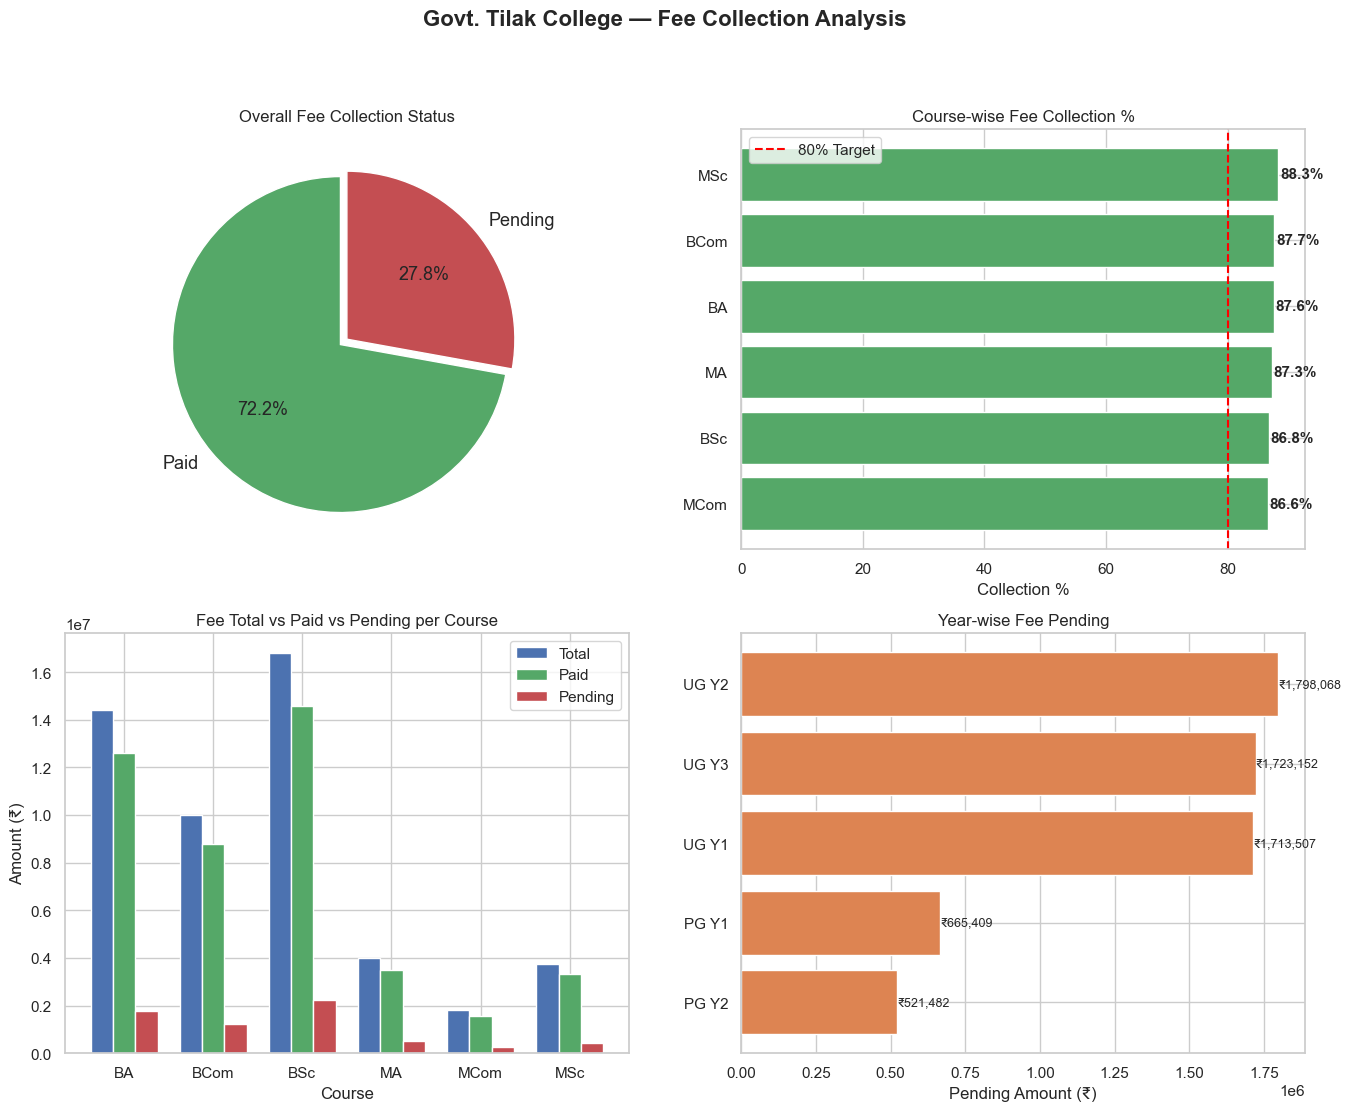

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Govt. Tilak College — Fee Collection Analysis', fontsize=16, fontweight='bold')
# Chart 1 — Overall Fee Collection Status (Pie)
fee_status = df_students['fee_status'].value_counts()
axes[0,0].pie(fee_status.values, labels=fee_status.index, autopct='%1.1f%%',
              colors=['#55A868', '#C44E52'], startangle=90,
              textprops={'fontsize': 13}, explode=(0.05, 0))
axes[0,0].set_title('Overall Fee Collection Status')

# Chart 2 — Course wise Fee Collection %
course_fee = df_students.groupby('course').agg(
    total_fee = ('fee_total', 'sum'),
    collected = ('fee_paid', 'sum')
).reset_index()
course_fee['collection_pct'] = (course_fee['collected'] / course_fee['total_fee'] * 100).round(2)
course_fee = course_fee.sort_values('collection_pct', ascending=True)

colors_fee = ['#C44E52' if x < 80 else '#55A868' for x in course_fee['collection_pct']]
axes[0,1].barh(course_fee['course'], course_fee['collection_pct'], color=colors_fee)
axes[0,1].axvline(x=80, color='red', linestyle='--', linewidth=1.5, label='80% Target')
axes[0,1].set_title('Course-wise Fee Collection %')
axes[0,1].set_xlabel('Collection %')
axes[0,1].legend()
for i, v in enumerate(course_fee['collection_pct']):
    axes[0,1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# Chart 3 — Total Fee vs Collected vs Pending (Bar)
course_fee_long = df_students.groupby('course').agg(
    Fee_Total   = ('fee_total', 'sum'),
    Fee_Paid    = ('fee_paid', 'sum'),
    Fee_Pending = ('fee_pending', 'sum')
).reset_index()

x = range(len(course_fee_long))
width = 0.25
axes[1,0].bar([i - width for i in x], course_fee_long['Fee_Total'],   width, label='Total',   color='#4C72B0')
axes[1,0].bar([i          for i in x], course_fee_long['Fee_Paid'],    width, label='Paid',    color='#55A868')
axes[1,0].bar([i + width  for i in x], course_fee_long['Fee_Pending'], width, label='Pending', color='#C44E52')
axes[1,0].set_title('Fee Total vs Paid vs Pending per Course')
axes[1,0].set_xlabel('Course')
axes[1,0].set_ylabel('Amount (₹)')
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(course_fee_long['course'])
axes[1,0].legend()    


# Chart 4 — Year wise Fee Pending
year_fee = df_students.groupby(['course_type', 'year']).agg(
    pending = ('fee_pending', 'sum')
).reset_index()
year_fee['label'] = year_fee['course_type'] + ' Y' + year_fee['year'].astype(str)
year_fee = year_fee.sort_values('pending', ascending=True)
axes[1,1].barh(year_fee['label'], year_fee['pending'], color='#DD8452')
axes[1,1].set_title('Year-wise Fee Pending')
axes[1,1].set_xlabel('Pending Amount (₹)')
for i, v in enumerate(year_fee['pending']):
    axes[1,1].text(v + 100, i, f'₹{v:,.0f}', va='center', fontsize=9)

In [96]:
plt.tight_layout()
plt.savefig('chart4_fee_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

<Figure size 1200x600 with 0 Axes>

Chart 4 saved!


In [97]:
# Fee Defaulters List
defaulters = df_students[df_students['fee_status'] == 'Pending'].sort_values(
    'fee_pending', ascending=False
)[['student_id', 'course', 'year', 'fee_total', 'fee_paid', 'fee_pending']].head(10)

total_pending = df_students['fee_pending'].sum()
total_collected = df_students['fee_paid'].sum()
collection_pct = (total_collected / df_students['fee_total'].sum() * 100)

print(f"\n💰 Fee Summary:")
print(f"   Total Fee Expected : ₹{df_students['fee_total'].sum():,.0f}")
print(f"   Total Collected    : ₹{total_collected:,.0f}")
print(f"   Total Pending      : ₹{total_pending:,.0f}")
print(f"   Collection Rate    : {collection_pct:.1f}%")
print(f"\n⚠️  Top 10 Fee Defaulters:")
print(defaulters.to_string(index=False))


💰 Fee Summary:
   Total Fee Expected : ₹50,750,000
   Total Collected    : ₹44,328,382
   Total Pending      : ₹6,421,618
   Collection Rate    : 87.3%

⚠️  Top 10 Fee Defaulters:
student_id course  year  fee_total  fee_paid  fee_pending
   GTC4798    MSc     1      15000      3072        11928
   GTC4706    MSc     1      15000      3607        11393
   GTC4601    MSc     2      15000      3950        11050
   GTC4623    MSc     1      15000      4002        10998
   GTC4646    MSc     2      15000      4068        10932
   GTC4789    MSc     2      15000      4111        10889
   GTC4699    MSc     2      15000      4231        10769
   GTC4679    MSc     2      15000      4415        10585
   GTC4758    MSc     2      15000      4721        10279
   GTC4777    MSc     2      15000      4818        10182


In [98]:
# FINAL SUMMARY DASHBOARD — Key KPI Cards + Overview

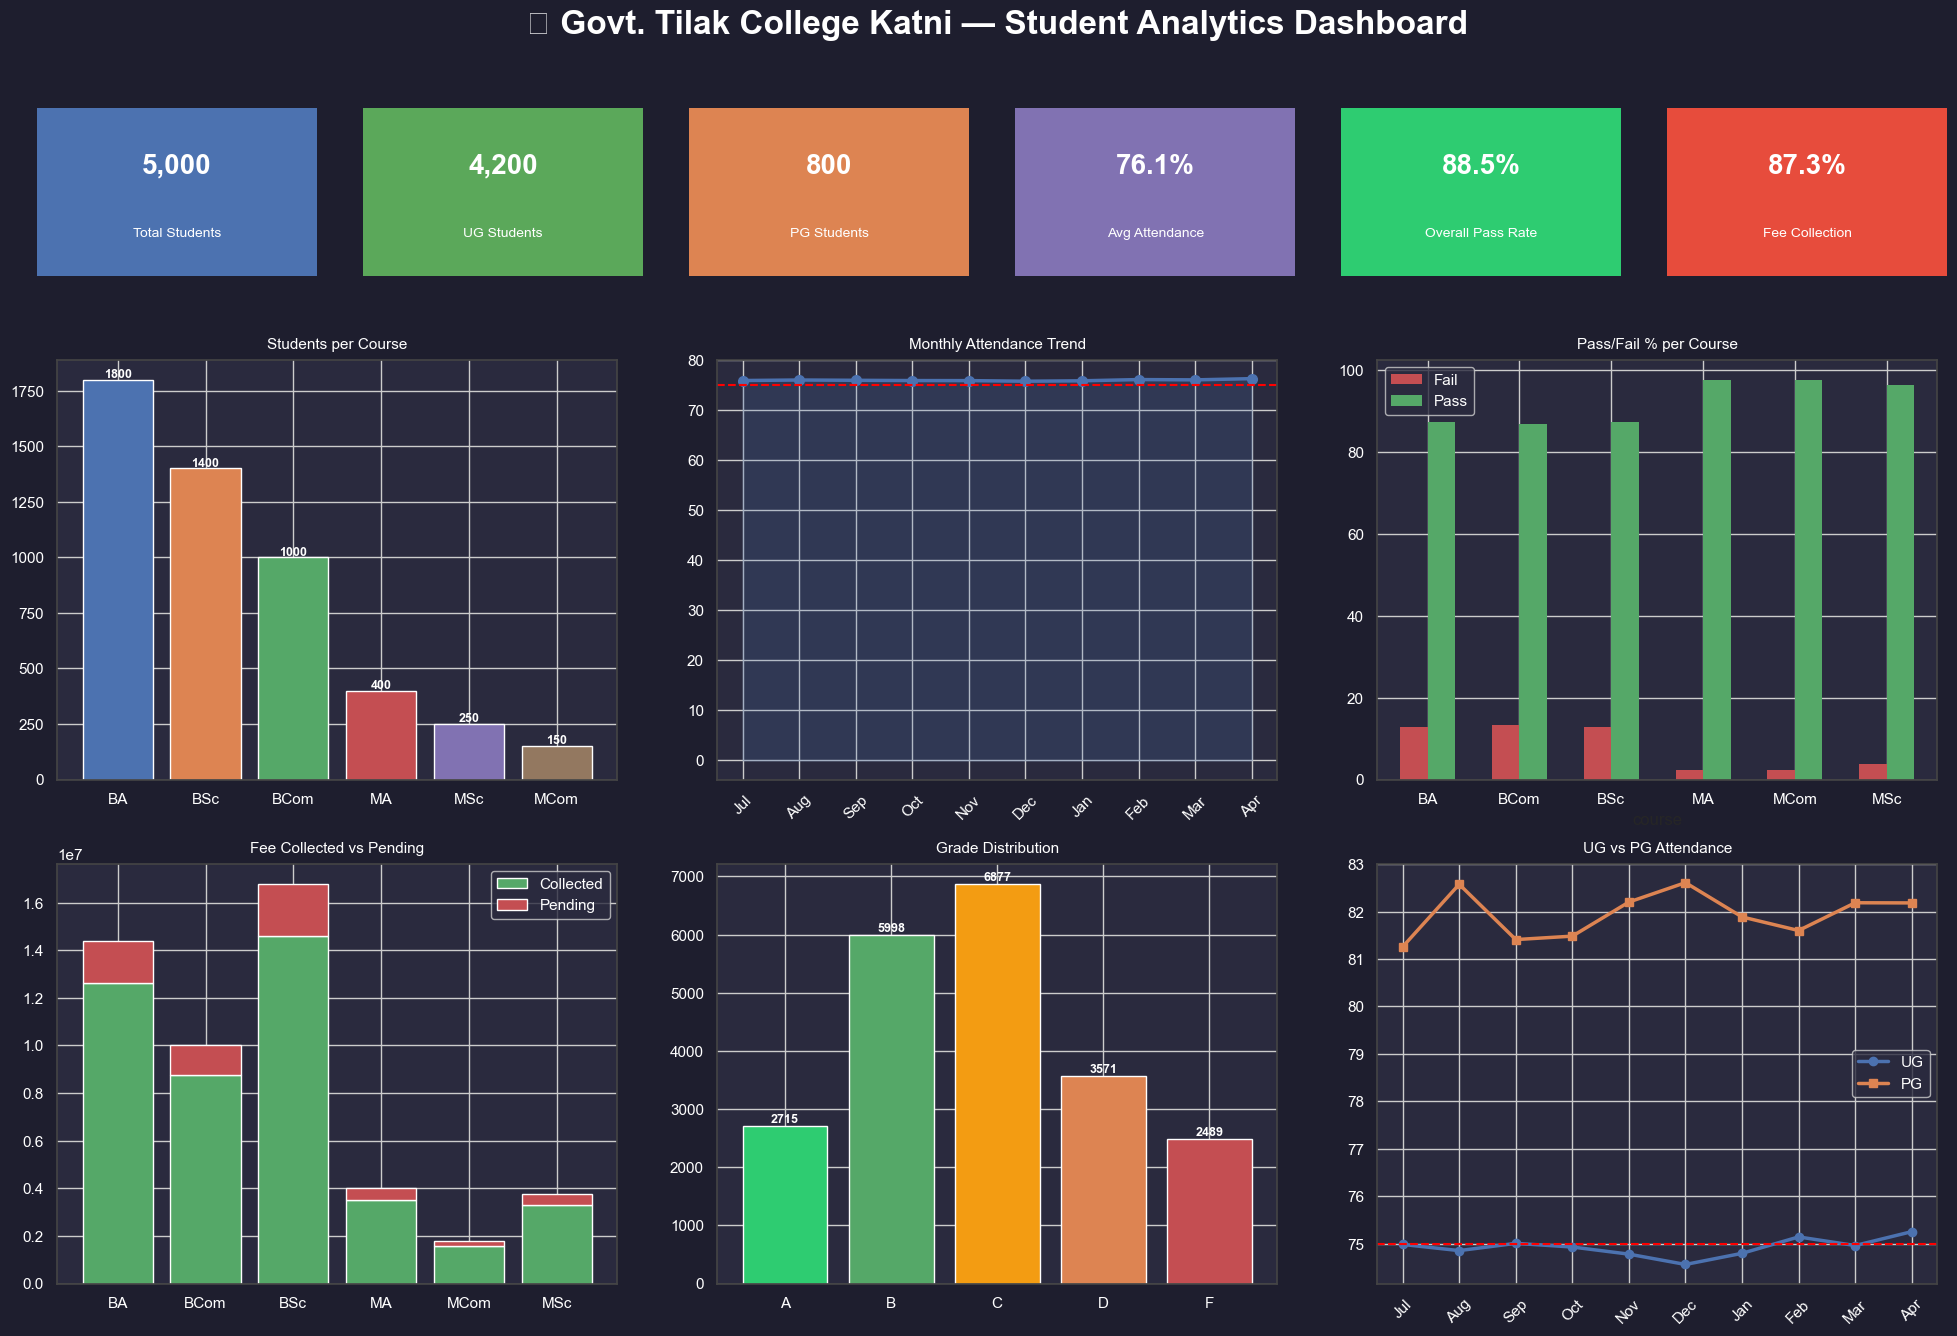

Summary Dashboard saved!


In [116]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#1e1e2e')

title = fig.text(0.5, 0.97, '🎓 Govt. Tilak College Katni — Student Analytics Dashboard',
                 ha='center', va='top', fontsize=24, fontweight='bold', color='white')

# ─── KPI CARDS (top row) ──────────────────────────────────────
kpis = [
    ('Total Students',    f"{len(df_students):,}",                          '#4C72B0'),
    ('UG Students',       f"{len(df_students[df_students['course_type']=='UG']):,}", '#5BA85A'),
    ('PG Students',       f"{len(df_students[df_students['course_type']=='PG']):,}", '#DD8452'),
    ('Avg Attendance',    f"{df_avg_attendance['overall_attendance_pct'].mean():.1f}%", '#8172B2'),
    ('Overall Pass Rate', f"{(df_marks['result']=='Pass').mean()*100:.1f}%",  '#2ecc71'),
    ('Fee Collection',    f"{collection_pct:.1f}%",                          '#e74c3c'),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_axes([0.02 + i*0.163, 0.78, 0.14, 0.12])
    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=20, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=10, color='white', transform=ax.transAxes)

# ─── CHART 1 — Course wise Students ──────────────────────────
ax1 = fig.add_axes([0.03, 0.42, 0.28, 0.30])
ax1.set_facecolor('#2a2a3e')
course_counts = df_students['course'].value_counts()
bars = ax1.bar(course_counts.index, course_counts.values,
               color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860'])
ax1.set_title('Students per Course', color='white', fontsize=11, pad=8)
ax1.tick_params(colors='white')
ax1.set_facecolor('#2a2a3e')
for spine in ax1.spines.values():
    spine.set_color('#444')
for bar, v in zip(bars, course_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 10, str(v),
             ha='center', color='white', fontsize=9, fontweight='bold')

# ─── CHART 2 — Monthly Attendance Trend ──────────────────────
ax2 = fig.add_axes([0.36, 0.42, 0.28, 0.30])
ax2.set_facecolor('#2a2a3e')
month_order = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr']
monthly_avg = df_attendance.groupby('month')['attendance_pct'].mean().reindex(month_order)
ax2.plot(monthly_avg.index, monthly_avg.values,
         marker='o', linewidth=2.5, color='#4C72B0', markersize=7)
ax2.fill_between(range(len(monthly_avg)), monthly_avg.values, alpha=0.2, color='#4C72B0')
ax2.axhline(y=75, color='red', linestyle='--', linewidth=1.5)
ax2.set_title('Monthly Attendance Trend', color='white', fontsize=11, pad=8)
ax2.set_xticks(range(len(month_order)))
ax2.set_xticklabels(month_order, rotation=45)
ax2.tick_params(colors='white')
ax2.set_facecolor('#2a2a3e')
for spine in ax2.spines.values():
    spine.set_color('#444')

# ─── CHART 3 — Pass/Fail per Course ──────────────────────────
ax3 = fig.add_axes([0.69, 0.42, 0.28, 0.30])
ax3.set_facecolor('#2a2a3e')
pass_fail = df_marks.groupby(['course', 'result']).size().unstack(fill_value=0)
pass_fail_pct = pass_fail.div(pass_fail.sum(axis=1), axis=0) * 100
pass_fail_pct.plot(kind='bar', ax=ax3,
                   color=['#C44E52', '#55A868'],
                   edgecolor='none', width=0.6)
ax3.set_title('Pass/Fail % per Course', color='white', fontsize=11, pad=8)
ax3.tick_params(colors='white')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, color='white')
ax3.legend(['Fail', 'Pass'], facecolor='#2a2a3e', labelcolor='white')
ax3.set_facecolor('#2a2a3e')
for spine in ax3.spines.values():
    spine.set_color('#444')

# ─── CHART 4 — Fee Collection ────────────────────────────────
ax4 = fig.add_axes([0.03, 0.06, 0.28, 0.30])
ax4.set_facecolor('#2a2a3e')
course_fee2 = df_students.groupby('course').agg(
    collected=('fee_paid', 'sum'),
    pending=('fee_pending', 'sum')
).reset_index()
x = range(len(course_fee2))
ax4.bar(x, course_fee2['collected'], label='Collected', color='#55A868')
ax4.bar(x, course_fee2['pending'], bottom=course_fee2['collected'],
        label='Pending', color='#C44E52')
ax4.set_title('Fee Collected vs Pending', color='white', fontsize=11, pad=8)
ax4.set_xticks(list(x))
ax4.set_xticklabels(course_fee2['course'], color='white')
ax4.tick_params(colors='white')
ax4.legend(facecolor='#2a2a3e', labelcolor='white')
ax4.set_facecolor('#2a2a3e')
for spine in ax4.spines.values():
    spine.set_color('#444')

# ─── CHART 5 — Grade Distribution ────────────────────────────
ax5 = fig.add_axes([0.36, 0.06, 0.28, 0.30])
ax5.set_facecolor('#2a2a3e')
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df_marks['grade'].value_counts().reindex(grade_order)
grade_colors = ['#2ecc71','#55A868','#f39c12','#DD8452','#C44E52']
ax5.bar(grade_counts.index, grade_counts.values, color=grade_colors)
ax5.set_title('Grade Distribution', color='white', fontsize=11, pad=8)
ax5.tick_params(colors='white')
ax5.set_facecolor('#2a2a3e')
for spine in ax5.spines.values():
    spine.set_color('#444')
for i, v in enumerate(grade_counts.values):
    ax5.text(i, v + 50, str(v), ha='center', color='white', fontsize=9, fontweight='bold')

# ─── CHART 6 — UG vs PG Attendance ──────────────────────────
ax6 = fig.add_axes([0.69, 0.06, 0.28, 0.30])
ax6.set_facecolor('#2a2a3e')
ug_pg_att = df_attendance.groupby(['month','course_type'])['attendance_pct'].mean().unstack()
ug_pg_att = ug_pg_att.reindex(month_order)
ax6.plot(range(len(month_order)), ug_pg_att['UG'],
         marker='o', linewidth=2.5, label='UG', color='#4C72B0')
ax6.plot(range(len(month_order)), ug_pg_att['PG'],
         marker='s', linewidth=2.5, label='PG', color='#DD8452')
ax6.axhline(y=75, color='red', linestyle='--', linewidth=1.5)
ax6.set_title('UG vs PG Attendance', color='white', fontsize=11, pad=8)
ax6.set_xticks(range(len(month_order)))
ax6.set_xticklabels(month_order, rotation=45, color='white')
ax6.tick_params(colors='white')
ax6.legend(facecolor='#2a2a3e', labelcolor='white')
ax6.set_facecolor('#2a2a3e')
for spine in ax6.spines.values():
    spine.set_color('#444')

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#1e1e2e')
plt.show()
print("Summary Dashboard saved!")

In [117]:
# ═══════════════════════════════════════════════════════════════
# ALL FILES CHECK — Kya kya bana
# ═══════════════════════════════════════════════════════════════

import os

files = [
    'students.csv',
    'attendance.csv', 
    'avg_attendance.csv',
    'marks.csv',
    'chart1_student_distribution.png',
    'chart2_attendance_analysis.png',
    'chart3_marks_analysis.png',
    'chart4_fee_analysis.png',
    'summary_dashboard.png',
]

print("📁 Project Files Status:")
print("=" * 45)
for f in files:
    exists = "✅" if os.path.exists(f) else "❌"
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"{exists} {f:40s} {size/1024:.1f} KB")
    else:
        print(f"{exists} {f}")

print("=" * 45)
print("✅ College Analytics Project — COMPLETE!")

📁 Project Files Status:
✅ students.csv                             289.9 KB
✅ attendance.csv                           1644.9 KB
✅ avg_attendance.csv                       168.5 KB
✅ marks.csv                                914.9 KB
✅ chart1_student_distribution.png          8.7 KB
✅ chart2_attendance_analysis.png           8.7 KB
✅ chart3_marks_analysis.png                8.7 KB
✅ chart4_fee_analysis.png                  8.7 KB
✅ summary_dashboard.png                    282.9 KB
✅ College Analytics Project — COMPLETE!
